# **Valuación de opciones exóticas - Asiáticas y con Barrera**
#### Paola A. Figueroa Álvarez
#### 25/abril/2026

## **Instrucciones**
- Integra el código visto en clase en un notebook y contesta las preguntas con base en lo que observas

## **MonteCarlo para opción Asiática**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Parámetros

S0 = 670
K = 680
r = 0.04
sigma = 0.17
N = 30          # numero de días
T = N/365       # tiempo al venc.
M = 10000       # numero de simulaciones
dt = T/N

Z = np.random.standard_normal((M,N))

retornos = (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z

S_paths = S0 * np.exp(np.cumsum(retornos, axis = 1))
S_paths = np.insert(S_paths, 0, S0, axis = 1)

# vector de precios al vencimiento
ST = S_paths[:,-1]
# vector de precios promedio de fluctuacion del subyacente
S_media = S_paths.mean(axis=1)

europea = np.exp(-r * T) * np.maximum(ST - K, 0)
asiatica = np.exp(-r * T) * np.maximum(S_media - K, 0)

# analítica Black Scholes
d1 = (np.log(S0 / K) + (r + 0.5 * sigma **2) * T / sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
bs_call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print("Precio Asiatica:",asiatica.mean())
print("Precio Europea:",europea.mean())
print("Precio Black Scholes:",bs_call)

Precio Asiatica: 3.753685227675268
Precio Europea: 9.291102432995563
Precio Black Scholes: 9.308744964731545


### **Visualización**

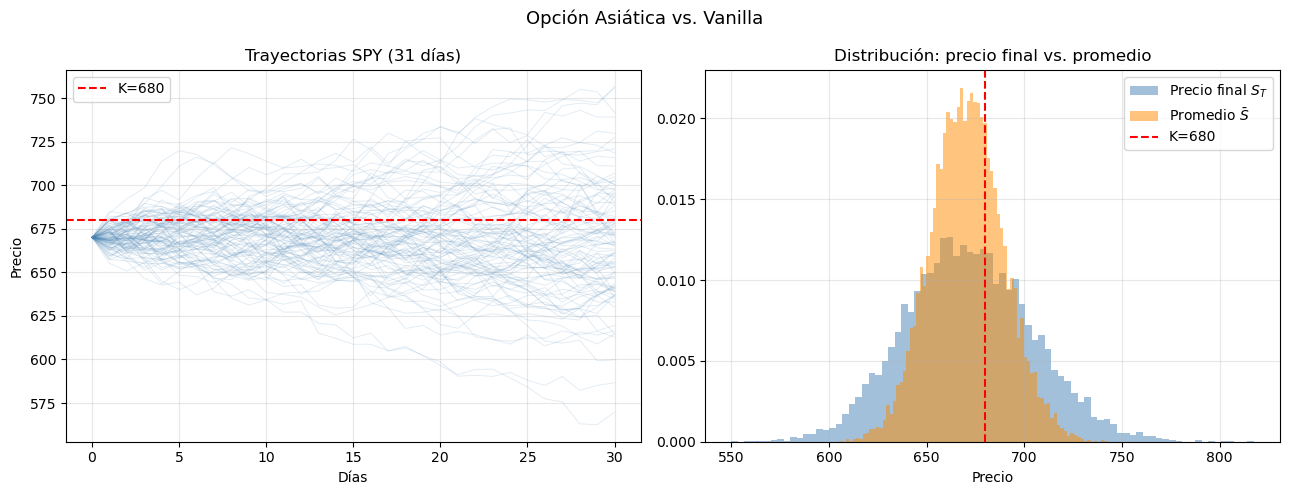

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trayectorias con el promedio marcado
for i in range(100):
    axes[0].plot(S_paths[i], alpha=0.15, linewidth=0.7, color='steelblue')
axes[0].axhline(K, color='red', linestyle='--', linewidth=1.5, label=f'K={K}')
axes[0].set_title('Trayectorias SPY (31 días)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución: precio final vs. promedio
axes[1].hist(ST,      bins=80, density=True, alpha=0.5,
             color='steelblue', label='Precio final $S_T$')
axes[1].hist(S_media, bins=80, density=True, alpha=0.5,
             color='darkorange', label='Promedio $\\bar{S}$')
axes[1].axvline(K, color='red', linestyle='--', label=f'K={K}')
axes[1].set_title('Distribución: precio final vs. promedio')
axes[1].set_xlabel('Precio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Opción Asiática vs. Vanilla', fontsize=13)
plt.tight_layout()
plt.show()

## **Opciones con Barrera**

In [3]:
B_up = 710

S_max = S_paths.max(axis=1)


# up and out
activa_up_and_out = (S_max < B_up)
call_up_and_out = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_out

# up and out
activa_up_and_in = (S_max > B_up)
call_up_and_in = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_in

print("up and out: ", call_up_and_out.mean())
print("up and in: ", call_up_and_in.mean())
print("europea", europea.mean())
print("comprobacion", call_up_and_out.mean() + call_up_and_in.mean()  )

up and out:  2.3233888239409977
up and in:  6.967713609054566
europea 9.291102432995563
comprobacion 9.291102432995563


### **Visualización**

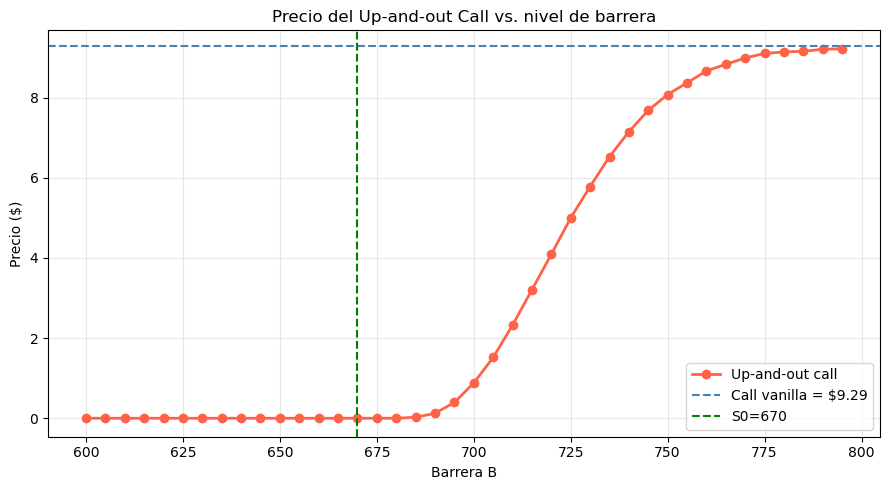

In [4]:
B_range = np.arange(600, 800, 5)   # barreras superiores
precios_uao = []

for b in B_range:
    s_max_b = S_paths.max(axis=1)
    precio  = np.exp(-r*T) * np.maximum(ST - K, 0) * (s_max_b < b)
    precios_uao.append(precio.mean())

plt.figure(figsize=(9, 5))
plt.plot(B_range, precios_uao, color='tomato', linewidth=2, marker='o',
         label='Up-and-out call')
plt.axhline(europea.mean(), color='steelblue', linestyle='--',
            linewidth=1.5, label=f'Call vanilla = ${europea.mean():.2f}')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Barrera B')
plt.ylabel('Precio ($)')
plt.title('Precio del Up-and-out Call vs. nivel de barrera')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Preguntas**
- **1.- La opción asiática es más barata que la vanilla. ¿Siempre es así? ¿Puedes pensar en algún caso donde fueran igual de caras?**
    - Por lo general sí son baratas ya que, como se ve en el código, el precio de la opción asiática (3.75) es menor al de la europea (9.29), indicando que la asiática depende del precio promedio del activo durante la vida de la opción. A la hora de promediar el precio, la volatilidad se reduce al payoff y, como el precio de una opción baja cuando la volatilidad disminuye, la asiática suele ser más económica. Podrían llegar a ser iguales si el subyacente tuviera un precio constante (poca o volatilidad nula) o si la opción tuviera un solo punto de observación para el promedio justo al vencimiento
- **2.- Verificaste que up-and-in + up-and-out = vanilla. ¿Qué implica eso para el pricing? ¿Puedes usarlo para encontrar el precio de una si conoces la otra?**
    - La paridad In-Out implica que una opción vanilla se puede descomponer en dos escenarios mutuamente excluyentes: o el precio toca la barrera en algún momento (se activa la "In") o nunca la toca (se mantiene viva la "Out"). Sí se puede usar para encontrar el precio de una conociendo la otra, ya que si conoces el precio de la opción vanilla (calculado por Black-Scholes) y tienes el precio de la opción up-and-out, puedes obtener el precio de la up-and-in simplemente restándolas (Despeje de la fórmula original: $Up-and-in + Up-and-out = Vanilla$): $In = Vanilla - Out$. 
- **3.-Si la barrera B está muy cerca de S0, el up-and-out call casi no vale nada. ¿Por qué? ¿Y si la barrera está muy lejos?**
    - Una opción up-and-out se cancela si el precio toca la barrera y si la barrera está muy cerca del precio inicial, la probabilidad de que el activo la toque rápidamente es altísima. Por lo tanto, es casi seguro que la opción se desactivará antes de llegar al vencimiento, haciendo que su valor sea casi cero. En el caso de que la barrera se aleje mucho o que tienda a infinito, la probabilidad de que el precio la toque disminuye. En este caso, el comportamiento de la opción se asemeja cada vez más al de una opción vanilla, ya que es muy improbable que muera (no importaría cuánto sube o baja el precio porque la opción vive hasta el día de vencimiento).
- **4.- ¿Por qué Monte Carlo es especialmente apropiado para opciones exóticas? ¿Cuál es su limitación principal vs. soluciones analíticas?**
    -  Es ideal para opciones dependientes de la trayectoria, porque permite simular paso a paso el camino del precio del activo. Las soluciones analíticas (fórmulas cerradas) suelen ser extremadamente complejas o imposibles de derivar para opciones que dependen de lo que pasó durante toda la vida del contrato y no solo al final. No obstante, su mayor desventaja es el costo computacional y precisión ya que, como vimos al inicio del semestre, una simulación Monte Carlo sigue la Ley de los Grandes Números donde, para obtener un precio exacto, habría que haber miles y miles de simulaciones, consumiendo tiempo y memoria (lenta convergencia). Además, el resultado siempre tendrá un pequeño error estadístico (ruido), a diferencia de la precisión exacta de una solución analítica.